
# QML-SleepNet — XAI & Causal Interpretability for Locked 90.1148% Final Ensemble — v1.2 AUDITED
## Recovered-roadmap Stage 09 · next functional stage in the frozen project

The recovered **QML-SleepNet Research Roadmap** labels interpretability/causal analysis as **Stage 09** and explicitly asks for:

### 9.1 Explainable AI (XAI)
- SHAP analysis
- feature importance
- class-specific explanations
- visualization of important time segments

### 9.2 Causal inference
- causal relationship analysis
- causal graph construction
- cross-signal interaction analysis

### 9.3 Sleep-physiology insights
- interpret model decisions
- connect model evidence to physiological variables
- identify candidate biomarkers / informative signals
- generate visual evidence

The current project has already diverged from the old roadmap where the dataset did not support the original five-class subtype route. Therefore **we move to the interpretability function now**, while retaining the correct roadmap label **Stage 09**.

---

# Frozen system being explained

Task A is the already-frozen **90.1148% official-x final ensemble**:

Prediction artifact SHA-256 is hard-locked in this notebook before any XAI runs.

Task A is frozen:

\[
\boxed{
\text{Bridge-HMM}
+
\text{QT Angle-Rx-HMM}
+
\text{corrected Stage06-HMM}
}
\]

with equal mean in logit space.

Task C is frozen separately as the development-selected downstream hard-run burden rule.

This notebook performs **explanation only**:

- NO retraining;
- NO model selection;
- NO threshold search;
- NO ensemble-weight change;
- NO HMM change;
- NO Task-A prediction change;
- NO Task-C prediction change.

---

# Explanation layers

This notebook intentionally separates different notions of "importance":

1. **Frozen SHAP-selected physiological features**  
   Reuses the Stage04 feature-selection artifact.  
   The persisted file contains the selected feature order but **not SHAP magnitudes**, so no SHAP magnitude is fabricated.

2. **Causal importance**  
   Reuses Stage05 ACE / `P(Y|do(X))` evidence and the frozen SCM outcome edges.

3. **Causal-gate utilization**  
   Reads the final Stage06 16→16 gate directly and measures how strongly each causal feature is passed through the final model.

4. **Exact branch contribution of the final ensemble**  
   Because the final blend is an equal mean in logit space, each branch's logit contribution is mathematically explicit.

5. **Bridge / QT latent-head attribution**  
   Uses exact linear-head logit decomposition. These are latent-dimension attributions, not physiological-feature claims.

6. **Important ECG time segments**  
   Uses gradient × input saliency for the **Stage06 branch** on a few deterministic, label-free representative x-set minutes.  
   This is a Stage06 branch explanation, not a claim that the full HMM ensemble is differentiable end-to-end.

7. **Task-C boundary trace**  
   Explains each record classification by its frozen estimated apnea-minute burden and distance from the fixed 5/100 boundaries.

The notebook saves all evidence to a new XAI folder but never changes a prediction.
---

## v1.2 audit corrections

This revision does **not** add a new model or explanation family. It only hardens provenance around the already-written Stage-09 XAI:

- hard-lock the exact final Task-A prediction SHA used by Stage-10;
- verify the saved official-x metric is the locked **90.1148%** result;
- fail closed if the final ensemble artifact has drifted;
- write XAI outputs to a new v1.2 evidence folder;
- preserve the original explanation-only boundary: **no training, no tuning, no prediction changes**.

This is the XAI stage for the final `Bridge-HMM + QT Angle-Rx-HMM + corrected Stage06-HMM`
equal-logit ensemble. It is not XAI for the 91.0192% classical benchmark.

### v1.1 UIDFIX
"
    "Stage05 `causal16_for_final_stage06.npz` stores `learn_uids`/`test_uids` as NumPy `object` arrays "
    "containing ordinary Python strings. v1 used `allow_pickle=False`, which correctly caused NumPy "
    "to refuse loading that object array. v1.1 enables pickle **only for this trusted project-generated "
    "Stage05 NPZ** and immediately validates that all loaded UID objects are strings. No model, metric, "
    "prediction, XAI method, or scientific decision was changed.

In [1]:

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, math, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = Path("/content/drive/MyDrive/QML_SleepNet")

BASE = ROOT / "outputs/GUIDE_EXACT_METRICMAX"

# Final frozen Task-A ensemble
ENS = BASE / "FINAL_FIXED_EQUAL_LOGIT_ENSEMBLE_v1"
ENS_X = ENS / "FINAL_FIXED_EQUAL_LOGIT_X_PREDICTIONS_FROZEN_BEFORE_SCORING.npz"
ENS_FREEZE = ENS / "FINAL_FIXED_EQUAL_LOGIT_PRE_SCORE_FREEZE_MANIFEST.json"
ENS_METRICS = ENS / "FINAL_FIXED_EQUAL_LOGIT_POSTHOC_X_METRICS.json"
ENS_PRED_CSV = ENS / "FINAL_FIXED_EQUAL_LOGIT_POSTHOC_X_PREDICTIONS.csv"

EXPECTED_FINAL_SHA = "f121a79191be00a28f33e06e7dec20cc689268b10a988c52e21284c90d1e2eef"
EXPECTED_OFFICIAL_ACCURACY_PCT = 90.1148

# Stage03 / Stage04 feature evidence
S3 = BASE / "03_feature_bank_v1"
S3_META = S3 / "guide_stage03_feature_metadata.csv"

BRIDGE = BASE / "04_bridge128to8_v1_3_fullgrid"
BRIDGE_PT = BRIDGE / "final_fit/bridge128to8_model.pt"
BRIDGE_QREADY = BRIDGE / "final_fit/quantum_ready_8d.npz"
SHAP_SELECTED = BRIDGE / "final_fit/shap_selected_features.csv"

S4 = BASE / "04_quantum_module_v3_audited"
QT_PT = S4 / "final_fit/final_qt_angle_rx.pt"
QFEATURES = S4 / "final_fit/quantum_features_for_final_stage06.npz"

# Stage05 causal evidence
S5 = BASE / "05_causal_core_v1_2"
CAUSAL16 = S5 / "final_fit/causal16_for_final_stage06.npz"
ACE = S5 / "final_fit/final_ace_ranking.csv"
GRAPHS = S5 / "final_fit/final_graphs.json"
MEDIATION = S5 / "final_fit/final_ecg_spo2_mediation.json"

# Stage06 final model
S6 = BASE / "05B_06_FINAL_GUIDE_CORRECTED_CONSOLIDATED_v1"
S6_PT = S6 / "final_fit/qml_sleepnet_final_guide_corrected.pt"
S2 = ROOT / "data/processed/stage02_preprocessed"

# Task-C frozen downstream rule
TASKC = BASE / "TASKC_METRICMAX_AGGREGATION_v1"
TASKC_X = TASKC / "TASKC_METRICMAX_X_PREDICTIONS_FROZEN_BEFORE_SCORING.csv"
TASKC_FREEZE = TASKC / "TASKC_FINAL_AGGREGATOR_FREEZE.json"

OUT = BASE / "XAI_CAUSAL_INTERPRETABILITY_90P1148_FINAL_v1_2"
OUT.mkdir(parents=True, exist_ok=True)

REQUIRED = [
    ENS_X, ENS_FREEZE, ENS_METRICS, ENS_PRED_CSV,
    S3_META,
    BRIDGE_PT, BRIDGE_QREADY, SHAP_SELECTED,
    QT_PT, QFEATURES,
    CAUSAL16, ACE, GRAPHS, MEDIATION,
    S6_PT,
    TASKC_X, TASKC_FREEZE,
]

missing = [str(p) for p in REQUIRED if not p.is_file()]
if missing:
    raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(missing))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FS = 100
EPOCH_SECONDS = 60
EPOCH_SAMPLES = FS * EPOCH_SECONDS
DROPOUT = 0.4
EPS = 1e-8

print("QML-SleepNet XAI / causal interpretability")
print("Device:", DEVICE)
print("Training: NO")
print("Prediction modification: NO")
print("Output:", OUT)


Mounted at /content/drive
QML-SleepNet XAI / causal interpretability
Device: cpu
Training: NO
Prediction modification: NO
Output: /content/drive/MyDrive/QML_SleepNet/outputs/GUIDE_EXACT_METRICMAX/XAI_CAUSAL_INTERPRETABILITY_90P1148_FINAL_v1_2


In [2]:

def sha256_file(path, chunk=1<<20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def atomic_json(path, obj):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=str))
    tmp.replace(path)

def atomic_csv(path, df):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=False)
    tmp.replace(path)

def logit(p):
    p = np.clip(np.asarray(p, dtype=np.float64), EPS, 1-EPS)
    return np.log(p) - np.log1p(-p)

def sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    return 1.0 / (1.0 + np.exp(-z))

def load_state(path):
    obj = torch.load(path, map_location="cpu", weights_only=False)
    if not isinstance(obj, dict):
        raise RuntimeError(f"{path.name}: checkpoint is not a dict")
    sd = obj.get("state_dict", obj)
    if not isinstance(sd, dict):
        raise RuntimeError(f"{path.name}: invalid state dict")
    return obj, sd

def align_by_uid(source_uids, values, target_uids):
    source_uids = np.asarray(source_uids).astype(str)
    target_uids = np.asarray(target_uids).astype(str)
    if len(np.unique(source_uids)) != len(source_uids):
        raise RuntimeError("duplicate source UID")
    pos = {u:i for i,u in enumerate(source_uids)}
    try:
        idx = np.asarray([pos[u] for u in target_uids], dtype=np.int64)
    except KeyError as e:
        raise RuntimeError(f"UID alignment failure: {e}")
    return np.asarray(values)[idx]

print("Helpers ready.")


Helpers ready.



# 1. Exact final-ensemble branch contribution

The final model is unusually interpretable at the final combination layer because it uses an equal mean of three post-HMM logits:

\[
L_{\mathrm{ensemble}}
=
\frac{1}{3}
\left(
L_{\mathrm{Bridge}}
+
L_{\mathrm{QT}}
+
L_{\mathrm{Stage06}}
\right)
\]

Therefore the signed contribution of branch \(j\) to the ensemble logit is exactly:

\[
c_j=\frac{1}{3}L_j
\]

This is not an approximation or post-hoc surrogate.


Final ensemble SHA verified: f121a79191be00a28f33e06e7dec20cc689268b10a988c52e21284c90d1e2eef
Locked official-x accuracy verified: 90.1148%
Exact logit reconstruction max error: 2.220446049250313e-16


,branch,mean_abs_logit_contribution,mean_signed_logit_contribution,mean_abs_contribution_predicted_apnea,mean_abs_contribution_predicted_normal,mean_branch_probability
0,Stage06-HMM,3.054262,-0.554419,3.109334,3.017646,0.417337
1,QT-AngleRx-HMM,2.865244,-0.807155,2.643277,3.012822,0.368969
2,Bridge-HMM,2.825648,-0.412186,2.978366,2.724111,0.421414


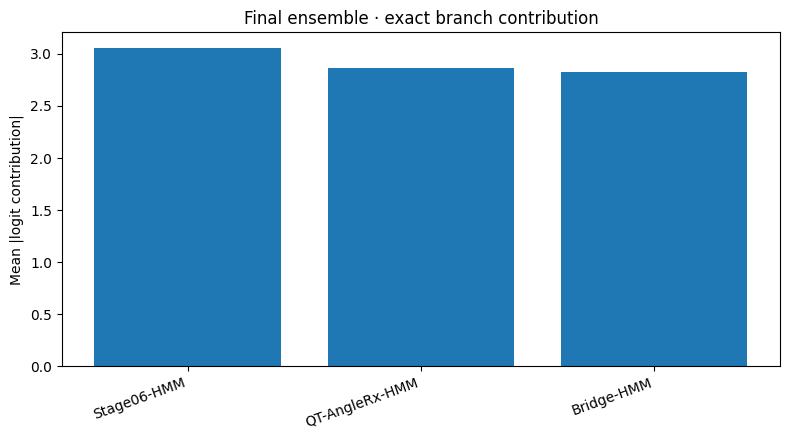

In [3]:

ens_manifest = json.loads(ENS_FREEZE.read_text())
ens_sha = sha256_file(ENS_X)

if ens_sha != ens_manifest["prediction_sha256"]:
    raise RuntimeError("Frozen final Task-A SHA mismatch")
if ens_sha != EXPECTED_FINAL_SHA:
    raise RuntimeError(
        f"Wrong final Task-A artifact for XAI: {ens_sha} != {EXPECTED_FINAL_SHA}"
    )

official_metrics = json.loads(ENS_METRICS.read_text())
official_acc = float(official_metrics["accuracy"])
if round(100.0 * official_acc, 4) != EXPECTED_OFFICIAL_ACCURACY_PCT:
    raise RuntimeError(
        f"Locked official-x accuracy drift: {100.0*official_acc:.8f}% "
        f"!= {EXPECTED_OFFICIAL_ACCURACY_PCT:.4f}%"
    )

z = np.load(ENS_X, allow_pickle=False)

UID = np.asarray(z["test_uids"]).astype(str)
P_B = np.asarray(z["bridge_hmm_posterior"], dtype=np.float64)
P_Q = np.asarray(z["qt_hmm_posterior"], dtype=np.float64)
P_S = np.asarray(z["stage06_hmm_posterior"], dtype=np.float64)
P_E = np.asarray(z["ensemble_hmm_logit_mean"], dtype=np.float64)
PRED = np.asarray(z["prediction"], dtype=np.int8)

if not (
    len(UID) == len(P_B) == len(P_Q) == len(P_S) == len(P_E) == len(PRED) == 17248
):
    raise RuntimeError("Frozen ensemble array geometry mismatch")

L = np.column_stack([logit(P_B), logit(P_Q), logit(P_S)])
CONTRIB = L / 3.0

# Reconstruct the saved ensemble exactly.
recon = sigmoid(CONTRIB.sum(axis=1))
max_diff = float(np.max(np.abs(recon - P_E)))
if max_diff > 1e-10:
    raise RuntimeError(f"Ensemble reconstruction mismatch: {max_diff}")

branch_names = ["Bridge-HMM", "QT-AngleRx-HMM", "Stage06-HMM"]

branch_rows = []
for j, name in enumerate(branch_names):
    branch_rows.append({
        "branch": name,
        "mean_abs_logit_contribution": float(np.mean(np.abs(CONTRIB[:,j]))),
        "mean_signed_logit_contribution": float(np.mean(CONTRIB[:,j])),
        "mean_abs_contribution_predicted_apnea": float(np.mean(np.abs(CONTRIB[PRED==1,j]))),
        "mean_abs_contribution_predicted_normal": float(np.mean(np.abs(CONTRIB[PRED==0,j]))),
        "mean_branch_probability": float(np.mean([P_B,P_Q,P_S][j])),
    })

BRANCH_DF = pd.DataFrame(branch_rows).sort_values(
    "mean_abs_logit_contribution", ascending=False
).reset_index(drop=True)

atomic_csv(OUT / "FINAL_ENSEMBLE_BRANCH_CONTRIBUTION.csv", BRANCH_DF)

print("Final ensemble SHA verified:", ens_sha)
print("Locked official-x accuracy verified:", f"{100.0*official_acc:.4f}%")
print("Exact logit reconstruction max error:", max_diff)
display(BRANCH_DF)

plt.figure(figsize=(8,4.5))
plt.bar(BRANCH_DF["branch"], BRANCH_DF["mean_abs_logit_contribution"])
plt.ylabel("Mean |logit contribution|")
plt.title("Final ensemble · exact branch contribution")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [4]:

# Deterministic, label-free representative cases.
branch_std = np.std(np.column_stack([P_B,P_Q,P_S]), axis=1)

rep_idx = {
    "high_confidence_apnea": int(np.argmax(P_E)),
    "high_confidence_normal": int(np.argmin(P_E)),
    "near_decision_boundary": int(np.argmin(np.abs(P_E - 0.5))),
    "maximum_branch_disagreement": int(np.argmax(branch_std)),
}

rep_rows = []
for role, i in rep_idx.items():
    rep_rows.append({
        "role": role,
        "uid": UID[i],
        "ensemble_probability": float(P_E[i]),
        "prediction": int(PRED[i]),
        "bridge_hmm": float(P_B[i]),
        "qt_hmm": float(P_Q[i]),
        "stage06_hmm": float(P_S[i]),
        "bridge_logit_contribution": float(CONTRIB[i,0]),
        "qt_logit_contribution": float(CONTRIB[i,1]),
        "stage06_logit_contribution": float(CONTRIB[i,2]),
        "branch_probability_std": float(branch_std[i]),
    })

REP_DF = pd.DataFrame(rep_rows)
atomic_csv(OUT / "REPRESENTATIVE_FINAL_ENSEMBLE_CASES.csv", REP_DF)

print("Deterministic representative final-ensemble cases")
display(REP_DF)


Deterministic representative final-ensemble cases


,role,uid,ensemble_probability,prediction,bridge_hmm,qt_hmm,stage06_hmm,bridge_logit_contribution,qt_logit_contribution,stage06_logit_contribution,branch_probability_std
0,high_confidence_apnea,x28:146,9.999989e-01,1,9.999997e-01,0.999980,9.999998e-01,4.983005,3.608267,5.151904,0.000009
1,high_confidence_normal,x29:16,1.942344e-07,0,2.453111e-10,0.000073,4.022399e-11,-6.140227,-3.173746,-6.140227,0.000035
2,near_decision_boundary,x19:168,5.008746e-01,1,4.525030e-01,0.208650,8.226110e-01,-0.063521,-0.444360,0.511380,0.252409
3,maximum_branch_disagreement,x07:485,9.730496e-01,1,9.999335e-01,0.999813,5.852709e-04,3.206093,2.861294,-2.480950,0.471069



# 2. Physiological-feature evidence: frozen SHAP selection

The Stage04 bridge retained a persisted `shap_selected_features.csv`.

Important limitation:

- it preserves the **selected feature IDs/names and saved order**;
- it does **not** preserve SHAP magnitude values.

Therefore this notebook reports the saved SHAP-selected feature set and its physiological metadata, but does not fabricate numeric SHAP values.


In [5]:

shap_sel = pd.read_csv(SHAP_SELECTED)
meta = pd.read_csv(S3_META)

if not {"feature_id","feature_name"}.issubset(shap_sel.columns):
    raise RuntimeError("Unexpected SHAP-selection schema")
if "feature" not in meta.columns:
    raise RuntimeError("Unexpected Stage03 metadata schema")

shap_sel = shap_sel.copy()
shap_sel["saved_selection_rank"] = np.arange(1, len(shap_sel)+1)

SHAP_META = shap_sel.merge(
    meta,
    left_on="feature_name",
    right_on="feature",
    how="left",
    validate="many_to_one",
)

cols = [
    "saved_selection_rank", "feature_id", "feature_name",
    "group", "temporal_scope", "source"
]
cols = [c for c in cols if c in SHAP_META.columns]

atomic_csv(OUT / "FROZEN_SHAP_SELECTED_FEATURES_WITH_METADATA.csv", SHAP_META)

print("Frozen SHAP-selected physiological features")
print("No SHAP magnitude is claimed because magnitude values were not persisted.")
display(SHAP_META[cols].head(30))


Frozen SHAP-selected physiological features
No SHAP magnitude is claimed because magnitude values were not persisted.


,saved_selection_rank,feature_id,feature_name,group,temporal_scope,source
0,1,317,cpcc_classic_cpc_top2_low_high_ratio,cardiopulmonary_coupling,centered_classic_cpc,reused_379_feature_cache
1,2,311,cpcc_classic_cpc_low,cardiopulmonary_coupling,centered_classic_cpc,reused_379_feature_cache
2,3,331,cpcp_classic_cpc_top2_low_high_ratio,cardiopulmonary_coupling,past_classic_cpc_overlapping,reused_379_feature_cache
3,4,115,cwtc_edr_cwt_apnea_low,edr_cwt,centered5,reused_379_feature_cache
4,5,366,ecg_mad,ecg_spectral_morphology,current_raw,reused_379_feature_cache
5,6,95,cvhrc_cvhr_lowband_power,cvhr,centered5,reused_379_feature_cache
6,7,325,cpcp_classic_cpc_low,cardiopulmonary_coupling,past_classic_cpc_overlapping,reused_379_feature_cache
7,8,123,cwtc_edr_cwt_ridge_iqr_hz,edr_cwt,centered5,reused_379_feature_cache
8,9,209,lsp_ls_peak_hz,rri_lomb_scargle,past5_overlapping,reused_379_feature_cache
9,10,70,ctxc_rr_robust_cv,rri_context,centered5,reused_379_feature_cache



# 3. Causal evidence: ACE + frozen outcome SCM

The implemented Stage05 causal core uses PC, FCI, NOTEARS, LiNGAM, a structural outcome model, and intervention analysis.

For the final outcome interpretation, the cleanest directional evidence is the persisted structural outcome edge set:

\[
X_i \rightarrow \mathrm{Apnea}
\]

with ACE computed from the Stage05 Q25/Q75 intervention protocol.

These are **model-based causal estimates under the Stage05 assumptions**. They are not clinical proof of causation.


Top Stage05 intervention-based causal effects


,feature,q25_standardized,q75_standardized,p_y1_do_q25,p_y1_do_q75,ace,abs_ace
0,qrs_p2p_median_current,-0.826018,0.577375,0.169171,0.681071,0.511900,0.511900
1,qrs_area_median_current,-0.789234,0.532063,0.594136,0.283364,-0.310772,0.310772
2,guide_qrs_amplitude,-0.795248,0.613159,0.580238,0.280468,-0.299770,0.299770
3,cur_pnn50,-0.805333,0.521407,0.465547,0.319693,-0.145854,0.145854
4,ecg_rms,-0.768998,0.566653,0.297332,0.436865,0.139533,0.139533
5,guide_qrs_duration_ms,-0.789737,0.858128,0.317239,0.438755,0.121516,0.121516
6,cur_rr_mean_s,-0.710027,0.680484,0.328209,0.448896,0.120687,0.120687
7,guide_p_wave_amplitude,-0.698522,0.518917,0.311710,0.416201,0.104492,0.104492
8,lsc_ls_hf_fraction,-0.673060,0.345726,0.426128,0.336292,-0.089836,0.089836
9,ecg_spectral_entropy,-0.124220,0.427274,0.346445,0.433887,0.087442,0.087442


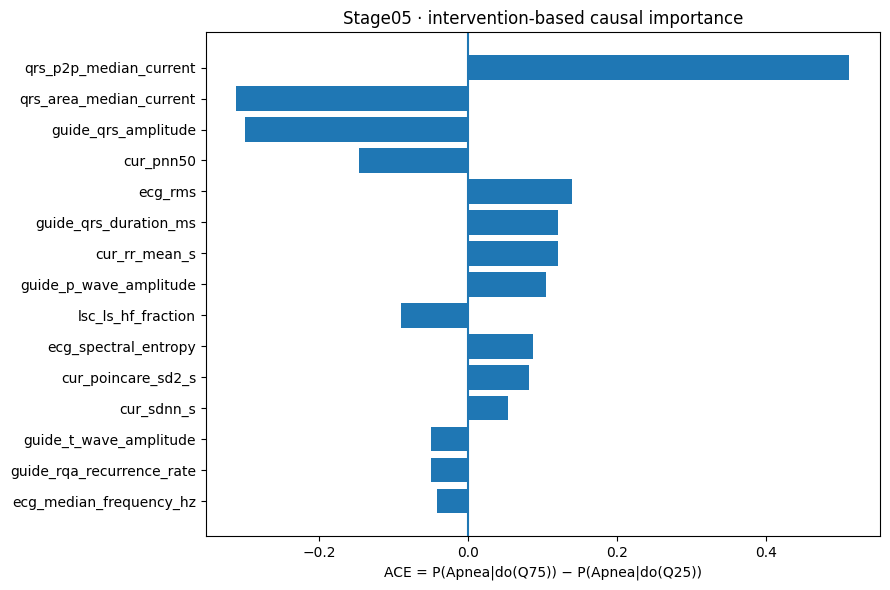


Persisted ECG→SpO2 / respiratory mediation evidence:
{
  "n_real_multimodal_rows": 3941,
  "mediator_path_a_ecg_to_spo2": 16.014671710182476,
  "outcome_path_b_spo2_to_apnea_logit": 0.2877993927227224,
  "approx_indirect_effect_a_times_b": 4.609012792844279,
  "direct_ecg_to_apnea_logit_adjusted_for_spo2": -4.993463580995035,
  "status": "regression-based mediation estimate; observational assumptions apply"
}


In [6]:

ace = pd.read_csv(ACE).sort_values("abs_ace", ascending=False).reset_index(drop=True)
graphs = json.loads(GRAPHS.read_text())
mediation = json.loads(MEDIATION.read_text())

required_ace = {
    "feature","q25_standardized","q75_standardized",
    "p_y1_do_q25","p_y1_do_q75","ace","abs_ace"
}
if not required_ace.issubset(ace.columns):
    raise RuntimeError("ACE schema mismatch")

atomic_csv(OUT / "FINAL_CAUSAL_ACE_RANKING_COPY.csv", ace)

print("Top Stage05 intervention-based causal effects")
display(ace.head(20))

plt.figure(figsize=(9,6))
top = ace.head(15).iloc[::-1]
plt.barh(top["feature"], top["ace"])
plt.axvline(0)
plt.xlabel("ACE = P(Apnea|do(Q75)) − P(Apnea|do(Q25))")
plt.title("Stage05 · intervention-based causal importance")
plt.tight_layout()
plt.show()

print("\nPersisted ECG→SpO2 / respiratory mediation evidence:")
print(json.dumps(mediation, indent=2))


In [7]:

# Conservative graph agreement audit.
# We do not reinterpret PC/FCI endpoint codes as definite direction here.
# Instead we ask whether each variable pair is connected/non-zero in each method.

nodes = graphs["node_names"]
method_arrays = {
    "PC": np.asarray(graphs["pc"]),
    "FCI": np.asarray(graphs["fci"]),
    "NOTEARS": np.asarray(graphs["notears"], dtype=float),
    "LiNGAM": np.asarray(graphs["lingam"], dtype=float),
}

for name, a in method_arrays.items():
    if a.shape != (len(nodes), len(nodes)):
        raise RuntimeError(f"{name}: graph shape mismatch")

pair_rows = []
for i in range(len(nodes)):
    for j in range(i+1, len(nodes)):
        support = {}
        for name, a in method_arrays.items():
            support[name] = bool(abs(float(a[i,j])) > 1e-12 or abs(float(a[j,i])) > 1e-12)

        n_support = int(sum(support.values()))
        if n_support:
            pair_rows.append({
                "feature_1": nodes[i],
                "feature_2": nodes[j],
                "method_support_count": n_support,
                **{f"present_{k}": v for k,v in support.items()}
            })

PAIR_DF = pd.DataFrame(pair_rows).sort_values(
    ["method_support_count","feature_1","feature_2"],
    ascending=[False,True,True]
).reset_index(drop=True)

atomic_csv(OUT / "CAUSAL_GRAPH_PAIRWISE_METHOD_SUPPORT.csv", PAIR_DF)

print("Cross-method graph connectivity support")
print("Direction is intentionally NOT inferred from mixed PC/FCI endpoint coding in this table.")
display(PAIR_DF.head(30))

scm_edges = pd.DataFrame(graphs["scm_outcome_parent_edges"])
atomic_csv(OUT / "SCM_OUTCOME_PARENT_EDGES.csv", scm_edges)

print("\nFrozen structural outcome edges → apnea")
display(scm_edges)


Cross-method graph connectivity support
Direction is intentionally NOT inferred from mixed PC/FCI endpoint coding in this table.


,feature_1,feature_2,method_support_count,present_PC,present_FCI,present_NOTEARS,present_LiNGAM
0,cur_rmssd_s,cur_poincare_sd1_s,4,True,True,True,True
1,cur_rr_mean_s,cur_pnn50,4,True,True,True,True
2,cur_rr_mean_s,ecg_rms,4,True,True,True,True
3,cur_sdnn_s,cur_poincare_sd2_s,4,True,True,True,True
4,cur_sdnn_s,cur_rmssd_s,4,True,True,True,True
5,ecg_median_frequency_hz,guide_t_wave_amplitude,4,True,True,True,True
6,ecg_spectral_entropy,ecg_median_frequency_hz,4,True,True,True,True
7,guide_qrs_amplitude,guide_p_wave_amplitude,4,True,True,True,True
8,guide_qrs_duration_ms,guide_p_wave_amplitude,4,True,True,True,True
9,guide_qrs_duration_ms,guide_qrs_amplitude,4,True,True,True,True



Frozen structural outcome edges → apnea


,from,to,edge_source,ace
0,qrs_p2p_median_current,apnea,structural logistic outcome SCM / ACE ranking,0.511900
1,qrs_area_median_current,apnea,structural logistic outcome SCM / ACE ranking,-0.310772
2,guide_qrs_amplitude,apnea,structural logistic outcome SCM / ACE ranking,-0.299770
3,cur_pnn50,apnea,structural logistic outcome SCM / ACE ranking,-0.145854
4,ecg_rms,apnea,structural logistic outcome SCM / ACE ranking,0.139533
5,guide_qrs_duration_ms,apnea,structural logistic outcome SCM / ACE ranking,0.121516
6,cur_rr_mean_s,apnea,structural logistic outcome SCM / ACE ranking,0.120687
7,guide_p_wave_amplitude,apnea,structural logistic outcome SCM / ACE ranking,0.104492
8,lsc_ls_hf_fraction,apnea,structural logistic outcome SCM / ACE ranking,-0.089836
9,ecg_spectral_entropy,apnea,structural logistic outcome SCM / ACE ranking,0.087442



# 4. Final Stage06 causal-gate utilization

The corrected Stage06 model gates the 16-D causal branch:

\[
g=\sigma(Wc+b),\qquad c_{\mathrm{gated}}=c\odot g
\]

This allows a direct explanation of **which causal coordinates the trained final model tends to pass through**.

Two quantities are reported:

- mean gate value;
- mean absolute gated input \(|c_i g_i|\).

The latter is a model-utilization proxy, not an ACE and not a SHAP value.


Final Stage06 causal-gate utilization


,feature,mean_gate,mean_abs_gated_input,mean_gate_predicted_apnea,mean_gate_predicted_normal,mean_abs_gated_input_predicted_apnea,mean_abs_gated_input_predicted_normal
0,qrs_area_median_current,0.558787,0.462537,0.573680,0.548884,0.543123,0.408959
1,ecg_rms,0.513137,0.461747,0.563279,0.479799,0.569279,0.390253
2,cur_pnn50,0.543232,0.452972,0.595565,0.508438,0.432479,0.466598
3,lsc_ls_hf_fraction,0.528155,0.436629,0.492830,0.551641,0.330966,0.506880
4,cur_rr_mean_s,0.464834,0.436557,0.447085,0.476635,0.348955,0.494801
5,guide_qrs_duration_ms,0.440173,0.417863,0.349581,0.500404,0.362900,0.454406
6,guide_rqa_recurrence_rate,0.550056,0.400004,0.570506,0.536460,0.284918,0.476521
7,lsc_ls_lf_hf_ratio,0.522620,0.395668,0.592230,0.476339,0.480619,0.339188
8,cur_poincare_sd2_s,0.498861,0.383635,0.514344,0.488567,0.411835,0.364886
9,guide_t_wave_amplitude,0.471252,0.355289,0.451007,0.484713,0.280991,0.404688


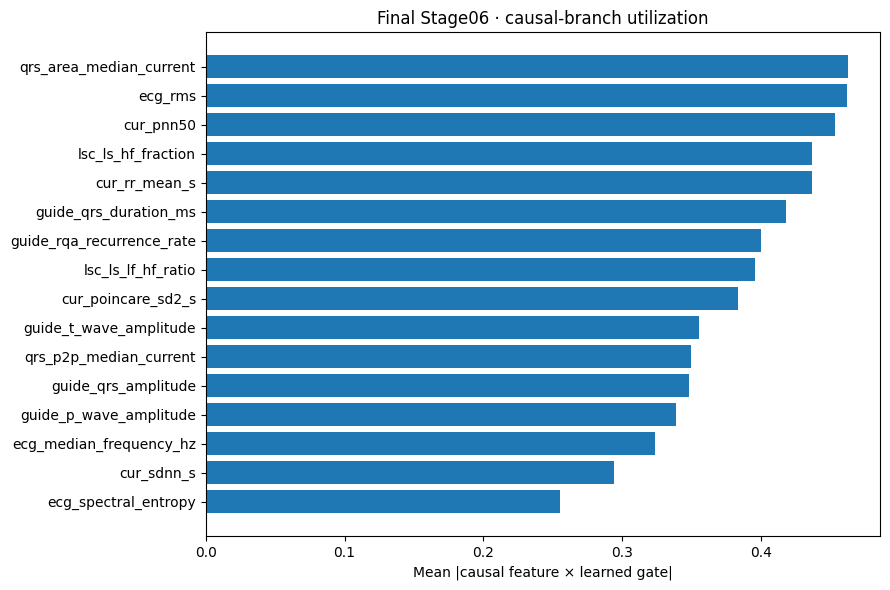

In [8]:

ckpt6, sd6 = load_state(S6_PT)
# Stage05 saved UID arrays as dtype=object (Python strings).
# This is a trusted project-generated NPZ, so pickle is enabled only for this file.
cdata = np.load(CAUSAL16, allow_pickle=True)

C_UID_RAW = np.asarray(cdata["test_uids"])
C_NAMES_RAW = np.asarray(cdata["feature_names"])

# Fail closed: pickle is needed only because test_uids was serialized as an object array.
# Validate that every object is an ordinary string before using it.
if C_UID_RAW.dtype == object:
    if not all(isinstance(x, str) for x in C_UID_RAW.tolist()):
        raise RuntimeError("CAUSAL16 test_uids contains a non-string object")
if C_NAMES_RAW.dtype == object:
    if not all(isinstance(x, str) for x in C_NAMES_RAW.tolist()):
        raise RuntimeError("CAUSAL16 feature_names contains a non-string object")

C_UID = C_UID_RAW.astype(str)
C_NAMES = C_NAMES_RAW.astype(str)
C_TEST = align_by_uid(C_UID, cdata["causal16_test"], UID).astype(np.float64)

if C_TEST.shape != (len(UID), 16) or len(C_NAMES) != 16:
    raise RuntimeError("causal16 final-test geometry mismatch")

Wg = sd6["causal_gate.weight"].detach().cpu().numpy().astype(np.float64)
bg = sd6["causal_gate.bias"].detach().cpu().numpy().astype(np.float64)

if Wg.shape != (16,16) or bg.shape != (16,):
    raise RuntimeError("Final causal-gate geometry mismatch")

GATE = sigmoid(C_TEST @ Wg.T + bg[None,:])
GATED = C_TEST * GATE

gate_rows = []
for j, name in enumerate(C_NAMES):
    gate_rows.append({
        "feature": name,
        "mean_gate": float(GATE[:,j].mean()),
        "mean_abs_gated_input": float(np.mean(np.abs(GATED[:,j]))),
        "mean_gate_predicted_apnea": float(GATE[PRED==1,j].mean()),
        "mean_gate_predicted_normal": float(GATE[PRED==0,j].mean()),
        "mean_abs_gated_input_predicted_apnea": float(np.mean(np.abs(GATED[PRED==1,j]))),
        "mean_abs_gated_input_predicted_normal": float(np.mean(np.abs(GATED[PRED==0,j]))),
    })

GATE_DF = pd.DataFrame(gate_rows).sort_values(
    "mean_abs_gated_input", ascending=False
).reset_index(drop=True)

atomic_csv(OUT / "FINAL_STAGE06_CAUSAL_GATE_UTILIZATION.csv", GATE_DF)

print("Final Stage06 causal-gate utilization")
display(GATE_DF)

plt.figure(figsize=(9,6))
plot = GATE_DF.iloc[::-1]
plt.barh(plot["feature"], plot["mean_abs_gated_input"])
plt.xlabel("Mean |causal feature × learned gate|")
plt.title("Final Stage06 · causal-branch utilization")
plt.tight_layout()
plt.show()



# 5. Exact latent-head attribution for Bridge and QT

Both final Bridge and QT artifacts expose a final two-class linear head.

For class margin:

\[
m(x)=\ell_{\mathrm{Apnea}}-\ell_{\mathrm{Normal}}
\]

the exact contribution of latent coordinate \(i\) at that head is:

\[
x_i(w_{1i}-w_{0i})
\]

This gives exact **latent-space** attribution at the branch head.

It does **not** mean that latent dimension 3, for example, is itself a named physiological variable.


In [9]:

# Bridge 8-D head decomposition
bq = np.load(BRIDGE_QREADY, allow_pickle=False)
B_UID = np.asarray(bq["test_uids"]).astype(str)
B_Z = align_by_uid(B_UID, bq["Z8_test"], UID).astype(np.float64)

_, sdb = load_state(BRIDGE_PT)
Bw = sdb["head.weight"].detach().cpu().numpy().astype(np.float64)
if Bw.shape != (2,8):
    raise RuntimeError("Bridge head geometry mismatch")

B_MARGIN_W = Bw[1] - Bw[0]
B_ATTR = B_Z * B_MARGIN_W[None,:]

bridge_attr = pd.DataFrame({
    "latent_dimension": [f"Bridge_Z8_{i}" for i in range(8)],
    "head_margin_weight": B_MARGIN_W,
    "mean_abs_margin_contribution": np.mean(np.abs(B_ATTR), axis=0),
    "mean_signed_margin_contribution": np.mean(B_ATTR, axis=0),
}).sort_values("mean_abs_margin_contribution", ascending=False)

atomic_csv(OUT / "BRIDGE_Z8_EXACT_HEAD_ATTRIBUTION.csv", bridge_attr)
print("Bridge Z8 exact linear-head attribution")
display(bridge_attr)

# QT 64-D head decomposition
q = np.load(QFEATURES, allow_pickle=False)
Q_UID = np.asarray(q["test_uids"]).astype(str)
Q_Z = align_by_uid(Q_UID, q["qt_angle64_test"], UID).astype(np.float64)

_, sdq = load_state(QT_PT)
Qw = sdq["head.weight"].detach().cpu().numpy().astype(np.float64)
if Qw.shape != (2,64):
    raise RuntimeError("QT head geometry mismatch")

Q_MARGIN_W = Qw[1] - Qw[0]
Q_ATTR = Q_Z * Q_MARGIN_W[None,:]

qt_attr = pd.DataFrame({
    "latent_dimension": [f"QT_Angle64_{i}" for i in range(64)],
    "head_margin_weight": Q_MARGIN_W,
    "mean_abs_margin_contribution": np.mean(np.abs(Q_ATTR), axis=0),
    "mean_signed_margin_contribution": np.mean(Q_ATTR, axis=0),
}).sort_values("mean_abs_margin_contribution", ascending=False)

atomic_csv(OUT / "QT_ANGLE64_EXACT_HEAD_ATTRIBUTION.csv", qt_attr)
print("\nQT Angle-Rx latent64 exact linear-head attribution — top 20")
display(qt_attr.head(20))


Bridge Z8 exact linear-head attribution


,latent_dimension,head_margin_weight,mean_abs_margin_contribution,mean_signed_margin_contribution
2,Bridge_Z8_2,-0.556907,0.439289,-0.245407
7,Bridge_Z8_7,0.542556,0.398858,0.035388
5,Bridge_Z8_5,0.504152,0.309065,0.012258
0,Bridge_Z8_0,-0.405053,0.205467,0.124508
6,Bridge_Z8_6,0.319391,0.201427,0.029283
1,Bridge_Z8_1,0.255318,0.190617,-0.189995
3,Bridge_Z8_3,-0.134821,0.079226,-0.027116
4,Bridge_Z8_4,0.158966,0.040693,-0.019480



QT Angle-Rx latent64 exact linear-head attribution — top 20


,latent_dimension,head_margin_weight,mean_abs_margin_contribution,mean_signed_margin_contribution
22,QT_Angle64_22,-0.172454,0.100275,-0.100275
60,QT_Angle64_60,-0.214668,0.099233,-0.099233
10,QT_Angle64_10,-0.199592,0.088914,-0.088914
44,QT_Angle64_44,-0.160029,0.086281,-0.086281
11,QT_Angle64_11,-0.100482,0.080421,-0.080421
31,QT_Angle64_31,-0.188826,0.078598,-0.078598
42,QT_Angle64_42,-0.108796,0.073509,-0.073509
6,QT_Angle64_6,-0.172383,0.072532,-0.072532
41,QT_Angle64_41,-0.155418,0.071974,-0.071974
12,QT_Angle64_12,-0.071343,0.069486,-0.069486



# 6. Important ECG time segments in the Stage06 branch

For the four deterministic representative cases selected earlier, we reconstruct the **exact final Stage06 model** and compute:

\[
\left|\frac{\partial(\ell_A-\ell_N)}{\partial x_t}\,x_t\right|
\]

for the normalized 60-second ECG.

The saliency is aggregated into one-second bins.

This satisfies the roadmap requirement to visualize important time segments while keeping the interpretation precise:

- it explains the differentiable Stage06 branch;
- it does not pretend the HMM or full ensemble is differentiable;
- it is not used to change any prediction.


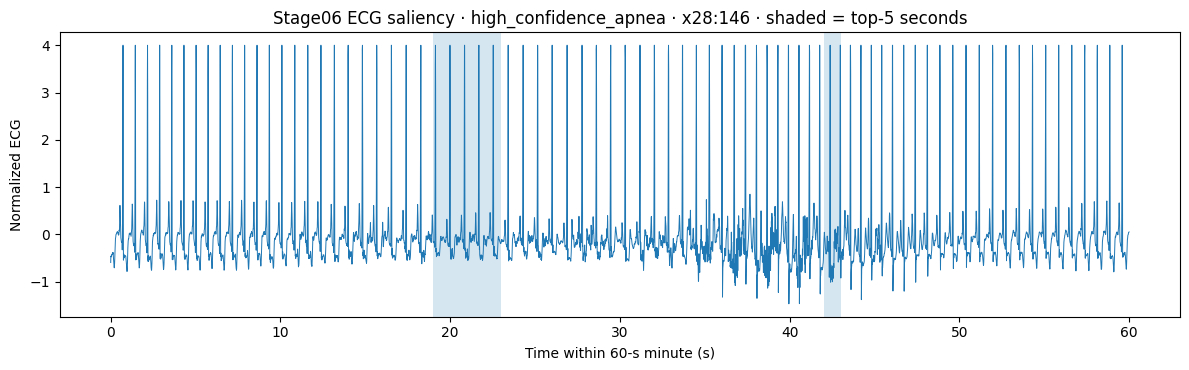

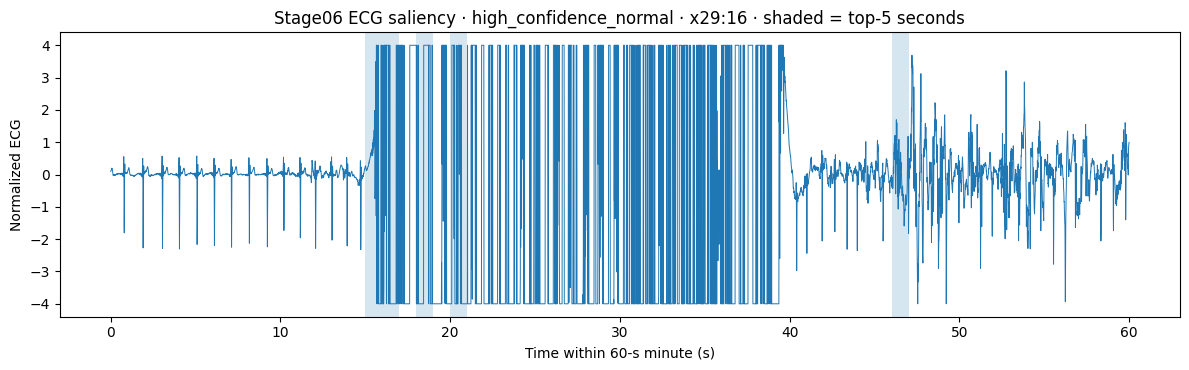

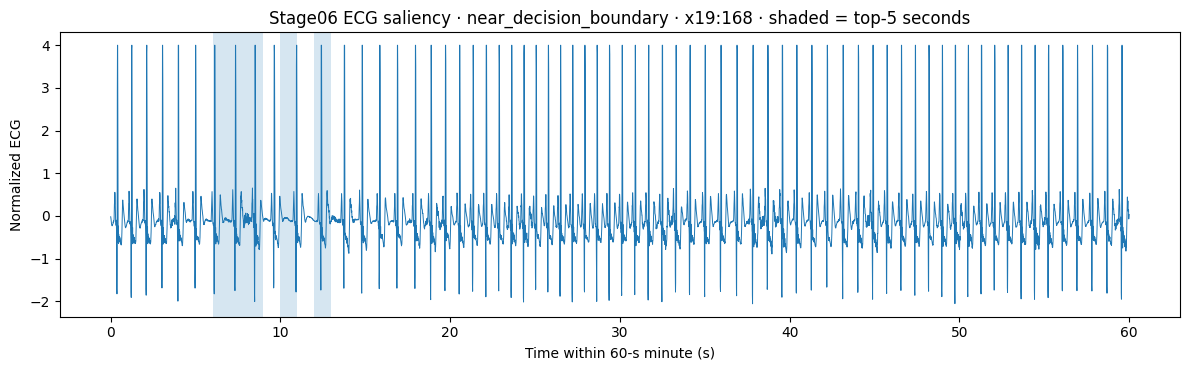

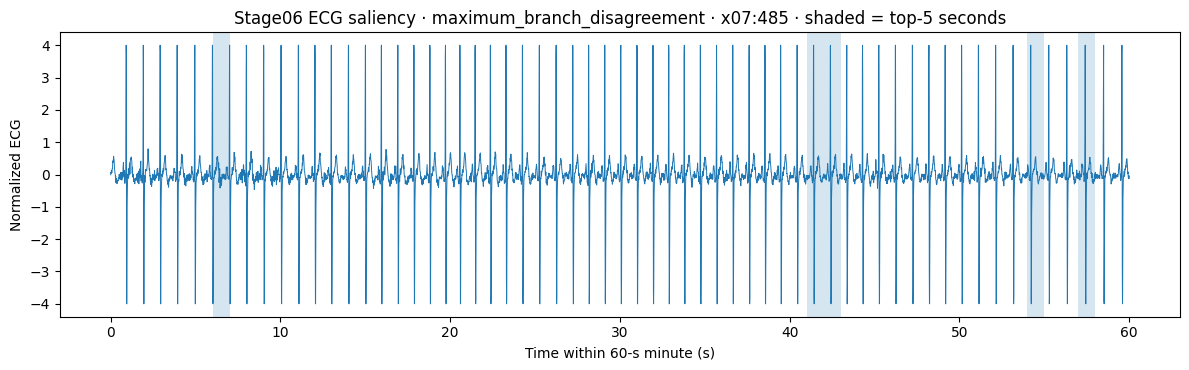

Top Stage06 time segments


,role,uid,ensemble_probability,stage06_hmm_probability,stage06_raw_logit_margin,rank,second_start,second_end,mean_abs_grad_x_input
0,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,1,21,22,0.018942
1,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,2,19,20,0.005216
2,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,3,20,21,0.004320
3,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,4,22,23,0.003004
4,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,5,42,43,0.002630
5,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,6,43,44,0.002294
6,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,7,10,11,0.001995
7,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,8,29,30,0.001929
8,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,9,41,42,0.001833
9,high_confidence_apnea,x28:146,9.999989e-01,9.999998e-01,3.428350,10,51,52,0.001769


In [10]:

class TemporalEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.c3 = nn.Conv1d(1,64,3,padding=1)
        self.c5 = nn.Conv1d(1,64,5,padding=2)
        self.c7 = nn.Conv1d(1,64,7,padding=3)
        self.bn = nn.BatchNorm1d(192)
        self.pool = nn.MaxPool1d(10,10)
        self.bilstm = nn.LSTM(
            192,128,num_layers=2,batch_first=True,
            bidirectional=True,dropout=DROPOUT
        )
        self.attn = nn.MultiheadAttention(
            256,1,dropout=DROPOUT,batch_first=True
        )

    def forward(self,x):
        h = torch.cat([self.c3(x),self.c5(x),self.c7(x)],dim=1)
        h = self.pool(F.relu(self.bn(h))).transpose(1,2)
        h,_ = self.bilstm(h)
        h,_ = self.attn(h,h,h,need_weights=False)
        return torch.cat([h.mean(dim=1),h.max(dim=1).values],dim=1)

class GuideHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.temporal = TemporalEncoder()
        self.causal_gate = nn.Linear(16,16)
        self.fusion256 = nn.Linear(536,256)
        self.fc128 = nn.Linear(256,128)
        self.fc64 = nn.Linear(128,64)
        self.out = nn.Linear(64,2)
        self.drop = nn.Dropout(DROPOUT)

    def forward(self,ecg,qml8,causal16):
        t = self.temporal(ecg)
        gate = torch.sigmoid(self.causal_gate(causal16))
        cg = causal16 * gate
        z = torch.cat([qml8,t,cg],dim=1)
        z = F.relu(self.fusion256(z))
        h = self.drop(F.relu(self.fc128(z)))
        h = self.drop(F.relu(self.fc64(h)))
        return self.out(h)

model = GuideHybrid().to(DEVICE)
missing, unexpected = model.load_state_dict(sd6, strict=False)
if missing or unexpected:
    raise RuntimeError(f"Stage06 state mismatch; missing={missing}, unexpected={unexpected}")
model.eval()

# Stage06 qml8 is the frozen VQC Angle-Rx 8-D feature bank.
Q8_TEST = align_by_uid(
    np.asarray(q["test_uids"]).astype(str),
    q["vqc_angle8_test"],
    UID
).astype(np.float32)

if Q8_TEST.shape != (len(UID),8):
    raise RuntimeError("Stage06 qml8 geometry mismatch")

def load_normalized_epoch(uid):
    rec, ep_s = uid.rsplit(":",1)
    ep = int(ep_s)
    p = S2 / f"{rec}_preprocessed.npz"
    if not p.is_file():
        raise FileNotFoundError(p)

    d = np.load(p,allow_pickle=False)
    ecg = np.asarray(d["ecg_filtered"],dtype=np.float32)
    fs = int(np.asarray(d["fs"]).item())
    ne = int(np.asarray(d["n_epochs"]).item())

    if fs != FS or len(ecg) != ne*EPOCH_SAMPLES:
        raise RuntimeError(f"{rec}: Stage02 ECG geometry mismatch")
    if ep < 0 or ep >= ne:
        raise RuntimeError(f"{uid}: epoch out of range")

    mu = float(ecg.mean())
    sd = float(ecg.std())
    if not np.isfinite(sd) or sd < 1e-8:
        raise RuntimeError(f"{rec}: invalid ECG SD")

    zrec = np.clip((ecg-mu)/sd,-4.0,4.0)
    return zrec[ep*EPOCH_SAMPLES:(ep+1)*EPOCH_SAMPLES].astype(np.float32)

saliency_rows = []

for role, idx in rep_idx.items():
    uid = UID[idx]
    x_np = load_normalized_epoch(uid)

    x = torch.tensor(
        x_np[None,None,:],
        dtype=torch.float32,
        device=DEVICE,
        requires_grad=True
    )
    q8 = torch.tensor(Q8_TEST[idx:idx+1],dtype=torch.float32,device=DEVICE)
    c16 = torch.tensor(C_TEST[idx:idx+1],dtype=torch.float32,device=DEVICE)

    model.zero_grad(set_to_none=True)
    logits = model(x,q8,c16)
    margin = logits[0,1] - logits[0,0]
    margin.backward()

    grad = x.grad.detach().cpu().numpy()[0,0]
    sal = np.abs(grad * x_np)

    sec_sal = sal.reshape(EPOCH_SECONDS,FS).mean(axis=1)
    top_seconds = np.argsort(sec_sal)[::-1][:10]

    for rank, sec in enumerate(top_seconds,1):
        saliency_rows.append({
            "role": role,
            "uid": uid,
            "ensemble_probability": float(P_E[idx]),
            "stage06_hmm_probability": float(P_S[idx]),
            "stage06_raw_logit_margin": float(margin.detach().cpu().item()),
            "rank": rank,
            "second_start": int(sec),
            "second_end": int(sec+1),
            "mean_abs_grad_x_input": float(sec_sal[sec]),
        })

    plt.figure(figsize=(12,3.8))
    t = np.arange(EPOCH_SAMPLES)/FS
    plt.plot(t,x_np,linewidth=0.7)
    top5 = top_seconds[:5]
    for sec in top5:
        plt.axvspan(sec,sec+1,alpha=0.18)
    plt.xlabel("Time within 60-s minute (s)")
    plt.ylabel("Normalized ECG")
    plt.title(f"Stage06 ECG saliency · {role} · {uid} · shaded = top-5 seconds")
    plt.tight_layout()
    plt.show()

SAL_DF = pd.DataFrame(saliency_rows)
atomic_csv(OUT / "STAGE06_IMPORTANT_ECG_TIME_SEGMENTS.csv", SAL_DF)

print("Top Stage06 time segments")
display(SAL_DF)



# 7. Task-C deterministic explanation

Task C is not a black-box record classifier.

Its frozen V1 rule is:

1. use the frozen Task-A posterior sequence;
2. count minutes passing the development-selected Task-C rule;
3. map the resulting burden to:
   - A: ≥100
   - B: 5–99
   - C: <5

Therefore a useful record-level explanation is simply:

- estimated apnea minutes;
- predicted A/B/C class;
- distance to the nearest fixed class boundary.


In [11]:

taskc_freeze = json.loads(TASKC_FREEZE.read_text())
taskc = pd.read_csv(TASKC_X)

required = {"record_name","estimated_apnea_minutes","taskc_predicted_class"}
if not required.issubset(taskc.columns):
    raise RuntimeError("Task-C frozen prediction schema mismatch")

def boundary_margin(n):
    n = float(n)
    if n < 5:
        return 5-n, "C/B boundary at 5"
    if n < 100:
        return min(n-5,100-n), "nearest of 5 or 100"
    return n-100, "B/A boundary at 100"

margins = taskc["estimated_apnea_minutes"].map(boundary_margin)
taskc["distance_to_nearest_boundary_minutes"] = [x[0] for x in margins]
taskc["boundary_context"] = [x[1] for x in margins]

taskc = taskc.sort_values(
    ["distance_to_nearest_boundary_minutes","record_name"]
).reset_index(drop=True)

atomic_csv(OUT / "TASKC_FROZEN_BOUNDARY_EXPLANATIONS.csv", taskc)

print("Task-C frozen aggregator:")
print(json.dumps(taskc_freeze["final_aggregator"], indent=2))
print("\nRecords nearest a fixed A/B/C boundary")
display(taskc.head(15))


Task-C frozen aggregator:
{
  "family": "hard_run_tuned",
  "threshold": 0.75,
  "min_run": 8,
  "development_all_oof_metrics": {
    "n_records": 35,
    "accuracy": 0.8571428571428571,
    "balanced_accuracy": 0.7999999999999999,
    "macro_f1": 0.783321941216678,
    "mcc": 0.7621267437763283,
    "recall_A": 0.9,
    "recall_B": 0.6,
    "recall_C": 0.9,
    "confusion_matrix": [
      [
        18,
        2,
        0
      ],
      [
        0,
        3,
        2
      ],
      [
        0,
        1,
        9
      ]
    ]
  }
}

Records nearest a fixed A/B/C boundary


,record_name,estimated_apnea_minutes,taskc_predicted_class,distance_to_nearest_boundary_minutes,boundary_context
0,x11,8.0,B,3.0,nearest of 5 or 100
1,x06,9.0,B,4.0,nearest of 5 or 100
2,x03,0.0,C,5.0,C/B boundary at 5
3,x04,0.0,C,5.0,C/B boundary at 5
4,x18,0.0,C,5.0,C/B boundary at 5
5,x22,0.0,C,5.0,C/B boundary at 5
6,x24,0.0,C,5.0,C/B boundary at 5
7,x29,0.0,C,5.0,C/B boundary at 5
8,x33,0.0,C,5.0,C/B boundary at 5
9,x34,0.0,C,5.0,C/B boundary at 5



# 8. Interpretation boundary

The following claims are allowed:

- which final ensemble branch contributes most in logit magnitude;
- which physiological variables were retained by the frozen SHAP-guided selection;
- which Stage05 variables have the largest model-based ACE;
- which causal coordinates the final Stage06 gate passes most strongly;
- which Bridge/QT latent coordinates dominate their own final linear heads;
- which ECG seconds have high Stage06 gradient×input saliency;
- why a Task-C record sits near/far from a fixed 5/100 boundary.

The following claims are **not** allowed:

- "this ECG second caused apnea";
- "SHAP proves causality";
- "ACE proves a clinical causal mechanism";
- "QT latent dimension 12 is HRV";
- "the quantum branch has proven quantum advantage";
- "A/B/C is standard clinical OSA severity";
- "the system diagnoses OSA/CSA/Mixed apnea".

This is a research explainability layer for the frozen QML-SleepNet pipeline.


In [12]:

manifest = {
    "schema": "QML_SleepNet_XAI_CAUSAL_INTERPRETABILITY_90P1148_FINAL_v1_2",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "roadmap_stage": "Stage 09 — Interpretability and Causal Analysis",
    "functional_position": "next implemented stage after frozen Task-A/Task-C classification work",
    "training_performed": False,
    "model_selection_performed": False,
    "taska_predictions_modified": False,
    "taskc_predictions_modified": False,
    "final_taska_prediction_sha256": ens_sha,
    "locked_official_x_accuracy": official_acc,
    "locked_official_x_accuracy_percent": 100.0 * official_acc,
    "explained_final_system": (
        "Bridge-HMM + QT Angle-Rx-HMM + corrected Stage06-HMM "
        "with equal mean in logit space"
    ),
    "xai_layers": [
        "exact final-ensemble logit contribution",
        "frozen SHAP-selected physiological feature inventory",
        "Stage05 ACE / SCM outcome-edge evidence",
        "cross-method causal-graph connectivity support",
        "final Stage06 causal-gate utilization",
        "Bridge Z8 exact linear-head attribution",
        "QT Angle-Rx latent64 exact linear-head attribution",
        "Stage06 gradient-times-input ECG time-segment saliency",
        "Task-C deterministic boundary explanation",
    ],
    "important_limitations": [
        "persisted SHAP selection does not include SHAP magnitude values",
        "ACE is model-based causal evidence under Stage05 assumptions, not clinical proof",
        "ECG gradient saliency explains Stage06 only, not the non-differentiable HMM/ensemble end-to-end",
        "Bridge and QT attributions are latent-space attributions",
        "no quantum-advantage claim",
    ],
    "outputs": {
        "branch_contribution": "FINAL_ENSEMBLE_BRANCH_CONTRIBUTION.csv",
        "representative_cases": "REPRESENTATIVE_FINAL_ENSEMBLE_CASES.csv",
        "shap_selected": "FROZEN_SHAP_SELECTED_FEATURES_WITH_METADATA.csv",
        "ace": "FINAL_CAUSAL_ACE_RANKING_COPY.csv",
        "graph_support": "CAUSAL_GRAPH_PAIRWISE_METHOD_SUPPORT.csv",
        "scm_edges": "SCM_OUTCOME_PARENT_EDGES.csv",
        "causal_gate": "FINAL_STAGE06_CAUSAL_GATE_UTILIZATION.csv",
        "bridge_latent": "BRIDGE_Z8_EXACT_HEAD_ATTRIBUTION.csv",
        "qt_latent": "QT_ANGLE64_EXACT_HEAD_ATTRIBUTION.csv",
        "ecg_time_segments": "STAGE06_IMPORTANT_ECG_TIME_SEGMENTS.csv",
        "taskc_boundary": "TASKC_FROZEN_BOUNDARY_EXPLANATIONS.csv",
    },
    "next_roadmap_stage": "Stage 10 — Model Robustness",
}

atomic_json(OUT / "XAI_FINAL_MANIFEST.json", manifest)

print("="*108)
print("QML-SLEEPNET 90.1148% FINAL-ENSEMBLE XAI / CAUSAL INTERPRETABILITY: COMPLETE")
print("="*108)
print("Task-A predictions changed: NO")
print("Task-C predictions changed: NO")
print("Training performed: NO")
print("Final Task-A SHA:", ens_sha)
print("Locked official-x accuracy:", f"{100.0*official_acc:.4f}%")
print("Evidence folder:", OUT)
print("NEXT RECOVERED-ROADMAP STAGE: Stage 10 — Model Robustness")


QML-SLEEPNET 90.1148% FINAL-ENSEMBLE XAI / CAUSAL INTERPRETABILITY: COMPLETE
Task-A predictions changed: NO
Task-C predictions changed: NO
Training performed: NO
Final Task-A SHA: f121a79191be00a28f33e06e7dec20cc689268b10a988c52e21284c90d1e2eef
Locked official-x accuracy: 90.1148%
Evidence folder: /content/drive/MyDrive/QML_SleepNet/outputs/GUIDE_EXACT_METRICMAX/XAI_CAUSAL_INTERPRETABILITY_90P1148_FINAL_v1_2
NEXT RECOVERED-ROADMAP STAGE: Stage 10 — Model Robustness
